# <b>Perform Pathway Enrichment</b>
Pathway enrichment analysis is performed on differentially expressed genes from CEBPE overactivation to identify biological processes and pathways systematically activated or suppressed by CEBPE perturbation in K562 cells.

---

## 1. Setup Environment

### 1.1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gseapy as gp
print("GSEAPY Version:", gp.__version__)

GSEAPY Version: 1.1.12


### 1.2. Define File Paths/Directories

In [2]:
import config

# DE Analysis results gene lists
DE_RESULTS_CSV_DIR = config.RESULTS_DIR / "04_de_analysis"
DE_RESULTS_CSV_UP = DE_RESULTS_CSV_DIR / "01_cebpe_vs_control_de_results_up.csv"
DE_RESULTS_CSV_DOWN = DE_RESULTS_CSV_DIR / "02_cebpe_vs_control_de_results_down.csv"
print("\nDE Analysis upregulated gene list:\n", DE_RESULTS_CSV_UP)
print("\nDE Analysis downregulated gene list:\n", DE_RESULTS_CSV_DOWN)

# Pathway enrichment results save location
PATHWAY_ENRICHMENT_RESULTS_DIR = config.RESULTS_DIR / "05_pathway_enrichment"
PATHWAY_ENRICHMENT_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print("\nPathway enrichment results will be saved to:\n", PATHWAY_ENRICHMENT_RESULTS_DIR)

# Figures save directory
FIGURES_DIR = config.FIGURES_DIR / "05_pathway_enrichment"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print("\nFigures will be saved to:\n", FIGURES_DIR)


DE Analysis upregulated gene list:
 ..\04_results\04_de_analysis\01_cebpe_vs_control_de_results_up.csv

DE Analysis downregulated gene list:
 ..\04_results\04_de_analysis\02_cebpe_vs_control_de_results_down.csv

Pathway enrichment results will be saved to:
 ..\04_results\05_pathway_enrichment

Figures will be saved to:
 ..\03_figures\05_pathway_enrichment


### 1.3. Define Global Parameters

In [3]:
SEED = config.SEED

np.random.seed(SEED)

print(f"\nRandom seed set to: {SEED}")


Random seed set to: 42


---

## 2. Load And Validate Data

### 2.1. Load DE Analysis Results Gene Lists

In [4]:
print("Loading DE results...")
upregulated = pd.read_csv(DE_RESULTS_CSV_UP)
downregulated = pd.read_csv(DE_RESULTS_CSV_DOWN)

print(f"DE results loaded.")
print(f"Upregulated genes: {len(upregulated)}")
print(f"Downregulated genes: {len(downregulated)}")

Loading DE results...
DE results loaded.
Upregulated genes: 604
Downregulated genes: 624


### 2.2. Inspect Data

In [5]:
print("Upregulated genes (first 5):")
print(upregulated.head())

print("\nDownregulated genes (first 5):")
print(downregulated.head())

Upregulated genes (first 5):
   names    scores  logfoldchanges          pvals      pvals_adj     log2fc  \
0  CEBPE  84.54104        7.253797   0.000000e+00   0.000000e+00  10.465016   
1   PLEK  58.33316        6.721716   0.000000e+00   0.000000e+00   9.697386   
2  TRGC1  36.93306        7.873339  1.362377e-298  9.169934e-296  11.358827   
3   LST1  56.95049        4.933288   0.000000e+00   0.000000e+00   7.117230   
4    FYB  35.46483        6.339189  1.713959e-275  1.064896e-272   9.145517   

   actual_fold_change  combined_rank  
0          1413.46100      613.24347  
1           830.24084      392.09894  
2          2626.31960      290.78650  
3           138.83527      280.95316  
4           566.33716      224.81827  

Downregulated genes (first 5):
          names     scores  logfoldchanges          pvals      pvals_adj  \
0          GYPA -30.352242       -1.588658  2.347025e-202  9.027106e-200   
1  RP11-717F1.1 -29.543165       -1.595441  8.038685e-192  2.705352e-189   
2 

### 2.3. Validate Data

In [6]:
# Concatenate up and downregulated results for sanity checks
de_results = pd.concat([upregulated, downregulated], ignore_index=True)

assert "names" in de_results.columns, "Gene names column missing"
assert "logfoldchanges" in de_results.columns, "Fold change column missing"
assert "pvals_adj" in de_results.columns, "Adjusted p-value column missing"
assert "log2fc" in de_results.columns, "log2fc column missing"
assert "actual_fold_change" in de_results.columns, "actual_fold_change column missing"
print("Required columns present")

assert len(de_results) == 1228, f"Expected 1,228 DE genes, got {len(de_results)}"
print(f"DE gene count verified: {len(de_results):,}")

assert upregulated.shape[0] == 604, f"Expected 604 upregulated, got {upregulated.shape[0]}"
assert downregulated.shape[0] == 624, f"Expected 624 downregulated, got {downregulated.shape[0]}"
print(f"Upregulated: {upregulated.shape[0]:,}, Downregulated: {downregulated.shape[0]:,}")

print("\nAll assertions passed.")

Required columns present
DE gene count verified: 1,228
Upregulated: 604, Downregulated: 624

All assertions passed.


---

## 3. Perform Pathway Enrichment

### 3.1. Define Gene Set Library List

In [7]:
# Gene set databases
GENE_SET_LIBRARIES = {
    # ARCHS4 Tissue signatures
    # Gene sets derived from tissue-specific expression profiles
    # Confirms whether CEBPE is shifting K562 toward neutrophil/myeloid tissue signature
    "ARCHS4_Tissues": "ARCHS4_Tissues",
    # ChEA - ChIP-seq based TF target library
    # Gene sets defined by ChIP-seq TF binding experiments
    # CEBPE itself should appear as top hit in upregulated genes — key validation
    "ChEA": "ChEA_2022",
    # Gene Ontology (GO) Biological Process
    # Collections of genes involved in specific biological activities
    # Examples: granulocyte differentiation, myeloid cell development, immune response
    "GOBP": "GO_Biological_Process_2025",
    # Kyoto Encyclopedia of Genes and Genomes (KEGG) - Human
    # Collections of genes in known metabolic and signaling pathways
    # Examples: Hematopoietic cell lineage, Acute myeloid leukemia
    "KEGG_Human": "KEGG_2026",
    # MSigDB Hallmark gene sets
    # Curated, high-quality gene sets representing well-defined biological states
    # Examples: Heme Metabolism, Inflammatory Response, myeloid differentiation
    "MSigDB_Hallmark": "MSigDB_Hallmark_2020",
    # Reactome Pathways
    # Collections of genes in molecular interaction networks
    # Examples: hematopoiesis, innate immune system, neutrophil degranulation
    "Reactome": "Reactome_Pathways_2024",
}

print("Gene set libraries selected:")
for key, lib in GENE_SET_LIBRARIES.items():
    print(f"  {key}: {lib}")

# Get the latest library names from the Enrichr server
names = gp.get_library_name()
df = pd.DataFrame(names, columns=["Latest Available GSEApy Library Names"])

from IPython.display import HTML

scrollable_html = f"""
<div style='height: 300px; overflow: auto; width: fit-content; border: 1px solid #ddd; padding: 10px;'>
    {df.to_html(index=False)}
</div>
"""

print("\nCross-check selected libraries against the latest available names below:")
display(HTML(scrollable_html))

Gene set libraries selected:
  ARCHS4_Tissues: ARCHS4_Tissues
  ChEA: ChEA_2022
  GOBP: GO_Biological_Process_2025
  KEGG_Human: KEGG_2026
  MSigDB_Hallmark: MSigDB_Hallmark_2020
  Reactome: Reactome_Pathways_2024

Cross-check selected libraries against the latest available names below:


Latest Available GSEApy Library Names
ARCHS4_Cell-lines
ARCHS4_IDG_Coexp
ARCHS4_Kinases_Coexp
ARCHS4_TFs_Coexp
ARCHS4_Tissues
Achilles_fitness_decrease
Achilles_fitness_increase
Aging_Perturbations_from_GEO_down
Aging_Perturbations_from_GEO_up
Allen_Brain_Atlas_10x_scRNA_2021


### 3.2. Perform Over-Representation Analysis (ORA)
Since the perturbation produces a strong, clean DE signal, ORA is the correct choice over GSEA (Gene Set Enrichment Analysis). GSEA is more appropriate when signal is subtle or distributed across many genes that individually fall below significance thresholds.

#### 3.2.1. Perform ORA On Upregulated Genes

In [ ]:
print("Running ORA on upregulated genes...")
enr_up = gp.enrichr(
    gene_list=upregulated["names"].tolist(),
    gene_sets=list(GENE_SET_LIBRARIES.values()),
    organism="human",
    outdir=str(
        PATHWAY_ENRICHMENT_RESULTS_DIR
        / "01_pathway_enrichment_upregulated"
        / "01_enrichr_results"
    ),
    cutoff=0.05,
)

print("\nORA complete.")
print(f"Upregulated results shape: {enr_up.results.shape}")

Running ORA on upregulated genes...

ORA complete.
Upregulated results shape: (4614, 10)


#### 3.3.2. Perform ORA On Downregulated Genes

In [9]:
print("\nRunning ORA on downregulated genes...")
enr_down = gp.enrichr(
    gene_list=downregulated["names"].tolist(),
    gene_sets=list(GENE_SET_LIBRARIES.values()),
    organism="human",
    outdir=str(
        PATHWAY_ENRICHMENT_RESULTS_DIR
        / "02_pathway_enrichment_downregulated"
        / "01_enrichr_results"
    ),
    cutoff=0.05,
)

print("\nORA complete.")
print(f"Downregulated results shape: {enr_down.results.shape}")


Running ORA on downregulated genes...

ORA complete.
Downregulated results shape: (4742, 10)


### 3.4. Visualize And Interpret Pathway Enrichment Results

#### 3.4.1. Visualize Results

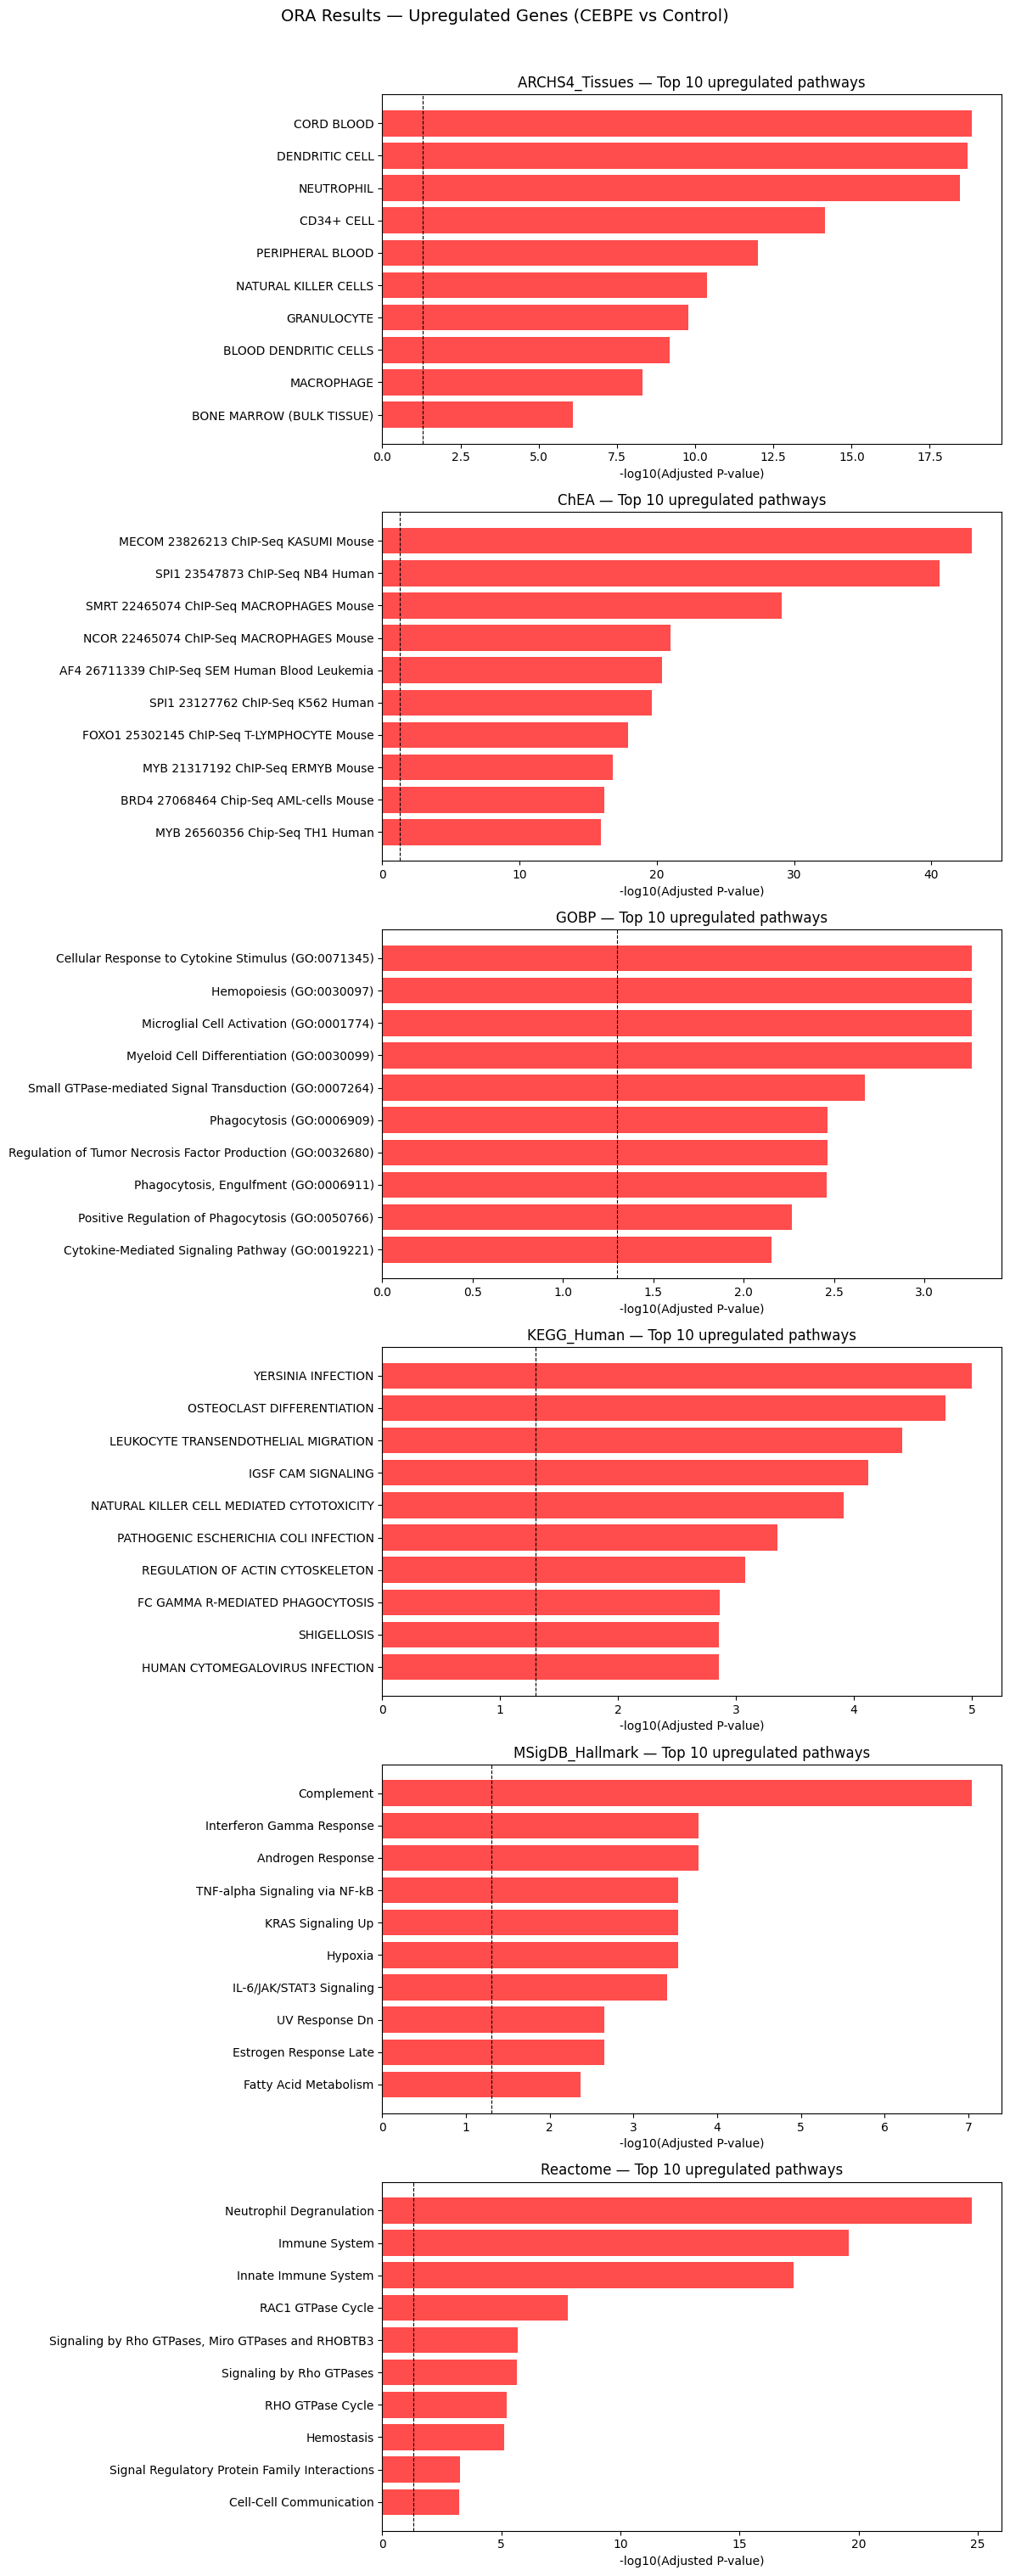

Saved: 01_ora_upregulated.png


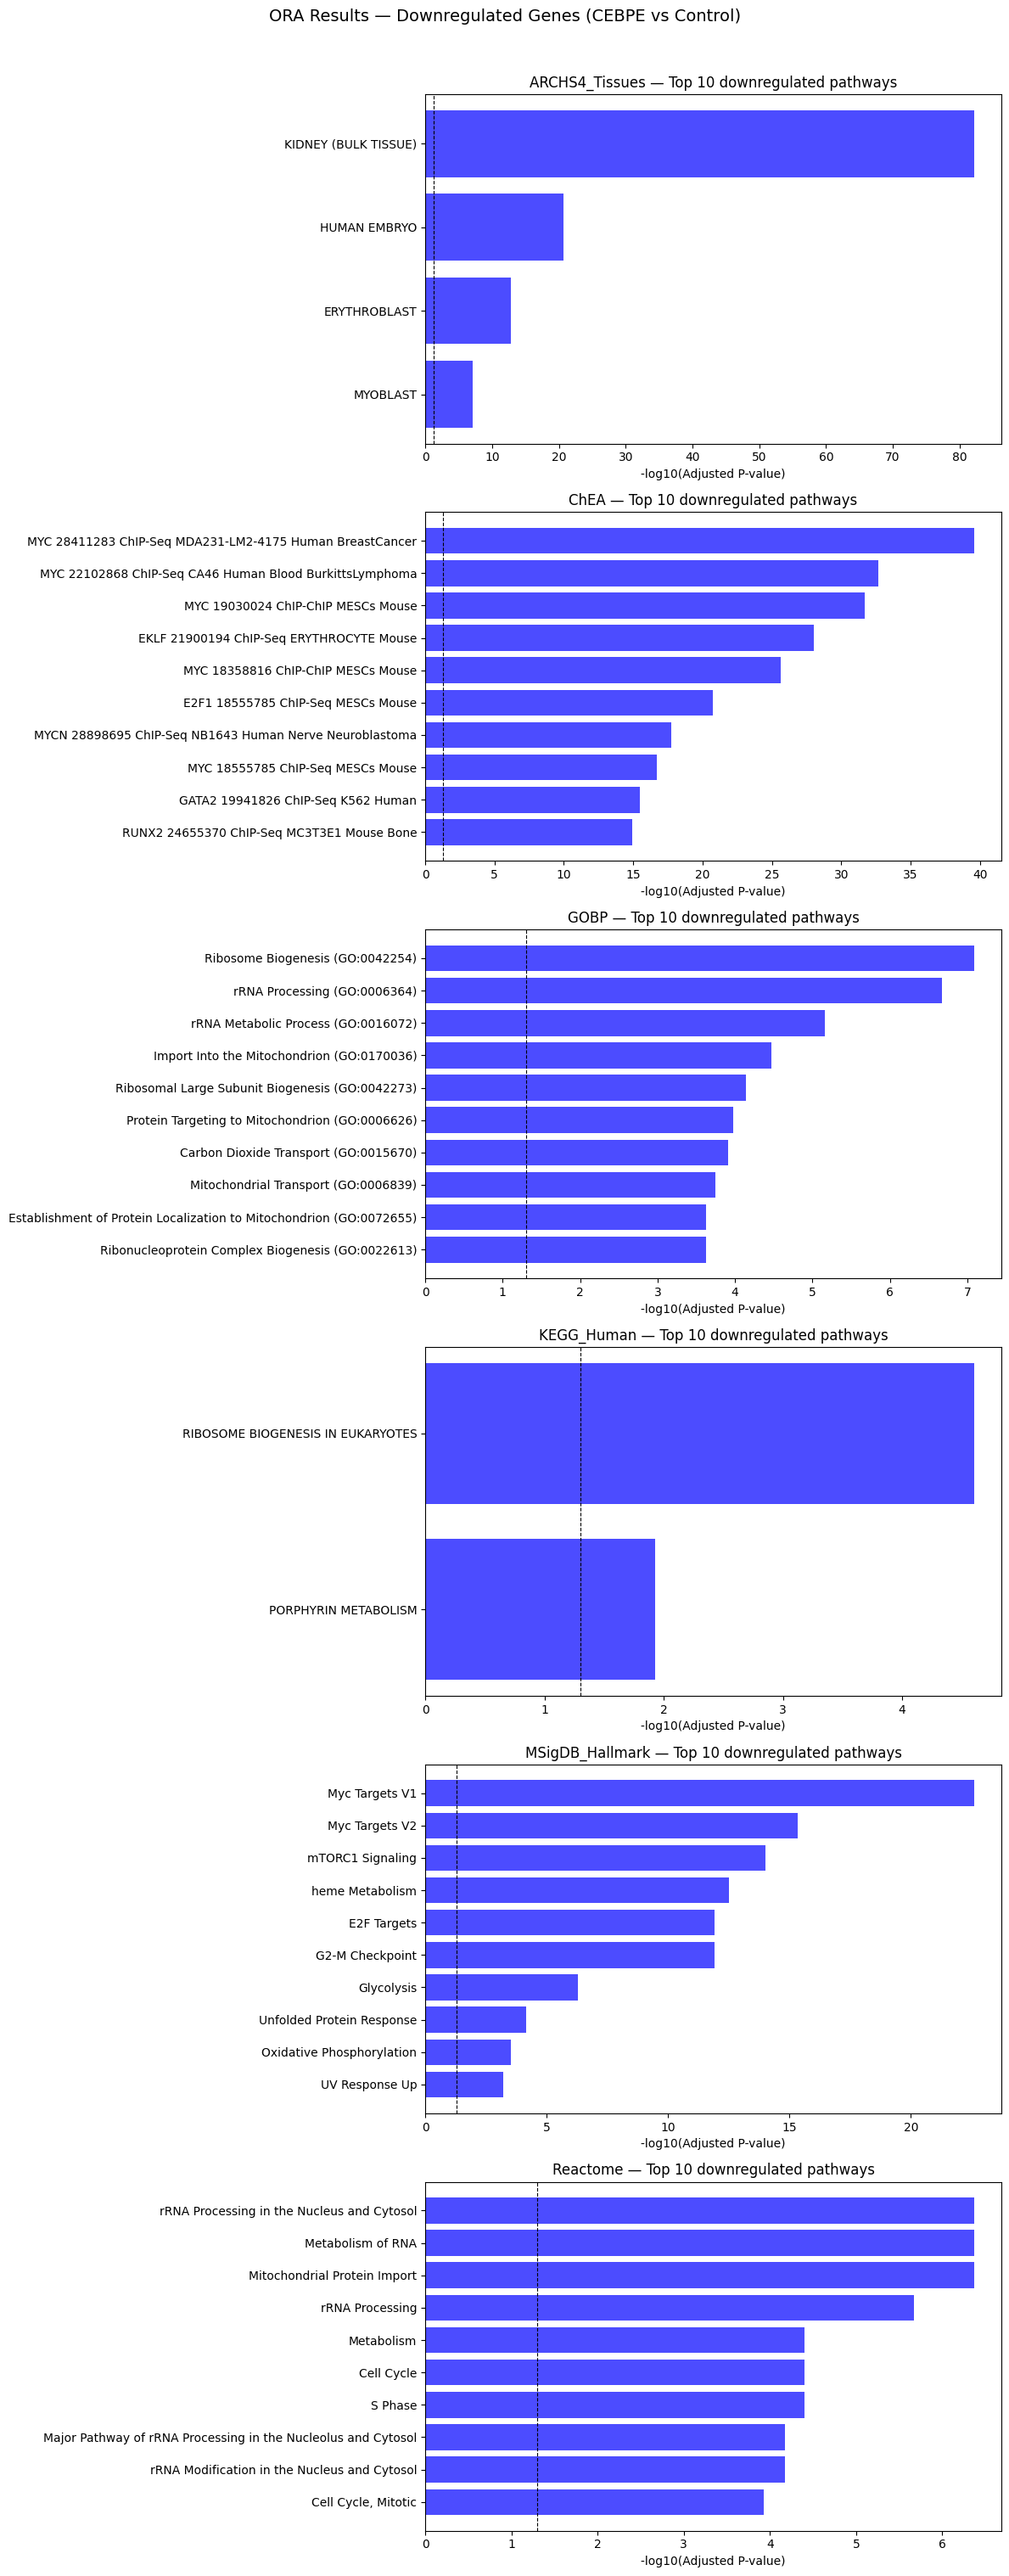

Saved: 02_ora_downregulated.png


In [10]:
def plot_top_pathways(enr_results, direction, top_n=10):
    fig, axes = plt.subplots(
        len(GENE_SET_LIBRARIES), 1, figsize=(12, 5 * len(GENE_SET_LIBRARIES))
    )

    for idx, (lib_key, lib_name) in enumerate(GENE_SET_LIBRARIES.items()):
        ax = axes[idx]

        # Filter to this library and significant results
        df = enr_results.results[
            (enr_results.results["Gene_set"] == lib_name)
            & (enr_results.results["Adjusted P-value"] < 0.05)
        ].copy()

        if len(df) == 0:
            ax.text(
                0.5,
                0.5,
                "No significant pathways",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )
            ax.set_title(f"{lib_key} — No significant results")
            continue

        # Take top N by adjusted p-value
        df = df.nsmallest(top_n, "Adjusted P-value")
        df["-log10(adj_pval)"] = -np.log10(df["Adjusted P-value"])
        df = df.sort_values("-log10(adj_pval)")

        ax.barh(
            df["Term"],
            df["-log10(adj_pval)"],
            color="red" if direction == "up" else "blue",
            alpha=0.7,
        )
        ax.axvline(x=-np.log10(0.05), color="black", linestyle="--", linewidth=0.8)
        ax.set_xlabel("-log10(Adjusted P-value)")
        ax.set_title(f"{lib_key} — Top {top_n} {direction}regulated pathways")
        plt.tight_layout()

    plt.suptitle(
        f"ORA Results — {direction.capitalize()}regulated Genes (CEBPE vs Control)",
        fontsize=14,
        y=1.01,
    )
    plt.tight_layout()

    filename = f"{'01' if direction == 'up' else '02'}_ora_{direction}regulated.png"
    plt.savefig(str(FIGURES_DIR / filename), bbox_inches="tight")
    plt.show()
    print(f"Saved: {filename}")


plot_top_pathways(enr_up, "up")
plot_top_pathways(enr_down, "down")

#### 3.4.2. Interpret Results

**Background Context**
- **Terminology:**
  - **Pathogen:** Foreign **organism** that contains antigens on it
  - **Antigen:** Specific type of **molecule** on a **pathogen**, recognized by the immune system
  - **Antibody:** Specific type of **protein** secreted by **plasma cells (activated B cells)** that recognizes and **binds to antigen** of pathogen to then neutralize it
  - **Transcription factor (TF)**: A protein that physically binds to genes in the DNA strand and regulates their expressions by either activating or supressing them (by either attracting transcription machinery towards the gene, or repelling them).
  - **Granules:** Specialized lysosomes filled with cytotoxins that kill/damage pathogens
  - **Degranulation:** Releasing of cytotoxins from within granules
  - **Hemopoiesis:** Process of producing new blood cells
  - **Effectors:** Cells that actively respond to stimuli
  - **Apoptosis:** Programmed cell death used to eliminate damaged/unnecessary cells without inflammation
  - **Biosynthesis:** Production of complex molecules within cells, such as proteins (e.g. antibodies, cytotoxins, etc.)

- **Types of Cytokines (i.e. signaling proteins that act as chemical messengers)**
  - **Interferons (IFNs):** Provide **antiviral** defense and inhibit viral replication
  - **Interleukins (ILs):** Mediate **interactions between WBCs** to regulate immune responses
  - **Chemokines:** Mediate **chemotaxis** by directing immune cells to infection sites
    -  **Chemotaxis:** Movement of cells/microbes toward/away from a stimulus, driven by chemical gradient in the environment
  - **Tumor Necrosis Factors (TNFs):** Regulate inflammation and **destroy tumor cells**
  - **Colony-Simulating Factors (CSFs):** Drive blood **stem cells to maturation**
  - **Transforming Growth Factors (TGFs):** Regulate cell growth, differentiation, and tissue repair

- **Classification of Blood Cells:**
  - **Based on lineage:**
    - **Myeloid lineage (from myeloid stem cells):**
      - **Red Blood Cells (RBCs)**
      - **Platelets (from megakaryocytes)**
      - **Granulocytes**:
        - WBCs that contain prominent cytoplasmic **granules**.
        - **Types:**
          - **Neutrophils:**
            - Most abundant granulocytes
            - Primary first responders
            - Neutralize pathogens by either:
              - **Phagocytosis**: Engulfing pathogens and then digesting it via **degranulation**
              - **NETs:** Releasing their DNA strands onto the pathogen to trap it, called **NET (Neutrophil Extracellular Trap)**.
          - **Eosinophils:** Release granules filled with highly caustic, **tissue-damaging proteins** to neutralize **large parasites**.
          - **Basophils:**
            - Trigger **inflammatory responses** by releasing granules filled with:
              - **Histamine:** increases blood flow to the site
              - **Heparin:** prevents blood clotting
            - Defend against **parasites**, similar to **eosinophils**
            - **Amplify allergic reactions**
              - **IgE antibodies** on basophil surface, upon detection of an **allergen**, trigger **massive degranulation**
                - Cause of **anaphylaxis** in severe allergies
      - **Mast cells:**
        - **Not true granulocytes**
          - **Contain granules** but are from a **different sublineage** than true granulocytes
        - **Tissue-resident** cells functionally similar to **basophils**
      - **Agranulocytes**:
        - WBCs that do **not** contain granules.
        - **Types:**
          - **Monocytes:**
            - **Macrophages:**
              - Engulf and digest pathogens (i.e. **phagocytosis**).
            - **Dendritic cells:** Capture and process **antigens**, then 'present' them to T cells to initiate a specific long-term immune memory.
              - **Bridge** between innate and adaptive immunity
    - **Lymphoid lineage (from lymphoid stem cells):**
      - **Lymphocytes:**
        - **Types:**
          - **T cells:**
            - **Types:**
              - **Killer T cells:** Neutralize infected host cells directly
              - **Helper T cells:** Coordinate broader immune responses by releasing signaling proteins like **IFN-γ**
              - **Memory T cells:** Persist after infection for faster/stronger future response to same pathogen; basis of vaccination
          - **B cells:**
            - **Types:**
              - **Plasma cells:** B cells differentiate into plasma cells upon activation, THEN produce antibodies
              - **Memory B cells:** Persist after infection for faster future antibody production in response to same pathogen
          - **Natural Killer (NK) cells:**
            - Directly kill virus-infected/tumor cells without needing prior sensitization/antigen presentation.
  - **Based on type of immunity**
    - **Innate immunity** (first responding, rapid, non-specific immune response)
      - **Neutrophils** (myeloid, granulocyte)
      - **Eosinophils** (myeloid, granulocyte)
      - **Basophils** (myeloid, granulocyte)
      - **Mast cells** (myeloid)
      - **Macrophages** (myeloid, agranulocyte)
      - **Natural Killer (NK) cells** (lymphoid, lymphocyte)
    - **Hybrid immunity** (bridge between innate and adaptive)
      - **Dendritic cells** (myeloid, agranulocyte)
        - **Reason:** They are the **most specialized APCs (Antigen Presenting Cells)** that present antigen fragments processed by innate immune cells to T cells (which are adaptive immune cells)
    - **Adaptive immunity** (slow, highly specific immune response)
      - **T cells** (lymphoid, lymphocyte)
      - **B cells** (lymphoid, lymphocyte)

---

##### 3.4.2.1. Biological Summary: CEBPE Overactivation in K562 Cells

K562 cells are a **human leukemia cell line** that was derived from a female patient with **CML (Chronic Myeloid Leukemia)**.
- **CML:** A type of blood cancer that starts in **myeloid stem cells** and primarily affects **granulocytes**.
- **Cause of CML:** An **acquired gene defect** (i.e. not congenital) that sends a constant signal to myeloid stem cells to:
  - **divide and survive indefinitely** (no apoptosis)
  - **without maturing** into functional granulocytes (mostly neutrophils, the most commonly produced granulocyte).

CEBPE is a **transcription factor** that, in normal **hematopoiesis**, signals immature myeloid cells to **exit the cell cycle (i.e. stop dividing) and differentiate into mature granulocytes**.
- CEBPE stands for **C**CAAT/**E**nhancer-**B**inding **P**rotein **E**psilon. Its a member of the **CEBP family of transcription factors**.
- The CEBP family was named as such because of:
  - **Sequence specificity:**
    - They are highly affinitive to the **CCAAT motif** (a specific sequence of DNA bases).
    - While they primarily target this motif, they can also bind to related sequences depending on their cooperative partner proteins.
  - **Enhancer-promoter interaction**:
    - The protein often binds to **enhancers**, which are regulatory DNA regions that can be located t**housands of base pairs away** from the target gene.
    - When a CEBP protein binds to an enhancer located in **euchromatin** (accessible regions of the DNA strand, as opposed to **heterochromatin**), it facilitates **DNA looping**.
    - This looping brings the distant **enhancer** into physical contact with the **promoter region** of the gene.
    - At the **promoter**, the CEBP protein interacts with the **general transcription machinery** (such as **RNA polymerase** and **cooperative partner proteins**) to initiate the gene's transcription.

By **overactivating** the *CEBPE* **gene** using CRISPRa, the K562 CML cells were forced towards maturation.

---

##### 3.4.2.2. Genes Activated By CEBPE Overactivation (604 Upregulated Genes)

- **Granulocytic differentiation program:**  
Genes that were upregulated in the experiment are strongly enriched for:
  - **Tissue signatures:**
    - The upregulated genes are typically found only in neutrophils and their precursors
    - **ARCHS4 Tissues enrichment** shows results for these categories:
      - Neutrophil
      - Granulocyte
      - CD34+ (granulocyte progenitor)
  - **Signaling pathways:**
    - **KEGG enrichment** shows:
      - **Leukocyte transendothelial migration**
      - **NK cell mediated cytotoxicity**
      - **FC gamma R-mediated phagocytosis**,
 
      consistent with mature myeloid cell function.
      - **Note:** Infection-related pathways (e.g. Yersinia, Shigella, E. coli) reflect **overlap with general innate immune gene sets** rather than actual infection response.
  - **Cell differentiation pathways:**
    - **GO Biological Process enrichment** shows results for **myeloid cell differentiation** and **hemopoiesis**.
      - **Note:** **Microglial** Cell Activation appears in GOBP results — **minor artifact** since **microglia are brain-resident macrophages** sharing gene expression signatures with myeloid cells generally.
  - **Functional markers:**
    - **Reactome enrichment** shows results for high activity in **neutrophil degranulation**

  This confirms CEBPE is pushing K562 cells toward their natural granulocytic differentiation target.

- **Immune and inflammatory activation:**  
**MSigDB Hallmark** enrichment shows that the cells are acquiring the machinery for **innate immune effector functions**. Specifically, the cells showed significant enrichment in:
  - **Complement system interaction:**
    - **Complement system:** A cascade of proteins that assists antibodies in neutralizing pathogens in two ways:
      - **Opsonization:**
        - Antibodies attach to antigens on a pathogen, enabling the **first proteins** of the cascade to **coat the pathogen**.
        - This in turn **helps neutrophils and macrophages** to identify and phagocytose the pathogen.
      - **Lysis via MAC:**
        - Since **antibodies cannot destroy pathogens directly**, they prime the pathogen's surface for the **final proteins of the complement cascade**. These proteins assemble into a **Membrane Attack Complex (MAC)** that **punctures the pathogen’s membrane**, causing **lysis** (cellular bursting) and death.
  - **Cytokine responsiveness:**
    - **Interferon gamma (IFN-γ):**
      - A **cytokine** that acts as a **bridge between innate and adaptive immunity** by:
        - **Innate Priming:** Increasing the killing efficiency (**phagocytosis** and **cytotoxicity**) of myeloid cells like **neutrophils** and **macrophages**.
        - **Antigen Presentation (the bridge):** Signals APCs to produce more **MHC molecules** on their surfaces.
          - **APC**: **A**ntigen **P**resenting **C**ells **(Dendrocytes/Macrophages)**
          - **MHC**: **M**ajor **H**istocompatibility **C**omplex (molecules that **hold the antigen fragments for presentation**)
          - Therefore, IFN-γ forces **APCs (which are innate immunity cells)** to produce more MHC molecules so that they can present more antigen fragments to **T cells (which are adaptive immunity cells)**, thereby initiating specific adaptive memory.
    - **TNF-α/NF-κB signaling:**
      - **TNF-α (Tumor Necrosis Factor - alpha)** signaling via **NF-κB** (**N**uclear **F**actor **k**appa-light-chain-enhancer of activated **B** cells)
      - **TNF-α:**
        - Protein secreted mainly by **activated macrophages**
        - Binds to surface of cells (ANY cells, not just blood cells) to enable **NF-κB** to enter the nucleus
      - **NF-κB**:
        - **Protein complex** that acts as a rapid-acting **transcription factor (TF)** that:
          - Enters the nucleus of the cell that TNF-α binds to
          - **Activates genes involved in immune responses, e.g. genes for cytokine production, anti-apoptosis, etc.**
          - Consequently, the cell **releases cytokines** to recruit and coordinate other **immune cells**, while simultaneously **upregulating survival genes** to **protect itself from the inflammatory environment**
        - First responder to harmful stimuli

  This indicates the K562 cells have transitioned from a "silent" proliferative state to a state capable of inflammatory signaling and pathogen recognition, characteristic of mature myeloid cells.

- **Regulatory Axis Activation:**  
**ChEA enrichment** identifies SPI1/PU.1 (K562 Human) as a top hit. SPI1 and PU.1 refer to the **exact same protein**, which is also a known cooperative partner of **CEBP family members** in myeloid differentiation, suggesting CEBPE overactivation **reactivates the broader PU.1-CEBP myeloid regulatory axis** in K562 cells.
  - **Note:** Several top ChEA hits are from **mouse ChIP-seq experiments** (e.g. KASUMI, MACROPHAGES). This is **expected** behavior for ChEA — **myeloid TF binding is conserved between human and mouse**, so these results remain **biologically informative**.

---

##### 3.4.2.3. Genes Suppressed By CEBPE Overactivation (624 downregulated genes)

- **Cell cycle:**  
  - **MSigDB Hallmark** shows:
    - MYC Targets V1/V2 (MYC is a TF that drives cell proliferation)
    - G2M Checkpoint (a state where the cell prepares to divide)
    - E2F Targets (E2F is a TF family that activates genes needed for DNA replication and S-phase entry)  

    as top suppressed gene sets.
  - **Reactome** shows Cell Cycle, S Phase, and Cell Cycle Mitotic suppression.

  This is the expected transcriptional signature of **cells exiting active proliferation** upon differentiation commitment.

- **Erythroid fate:**  
  - **ARCHS4** shows:
    - **Erythroblast suppression**
    - **Kidney bulk tissue:** Likely a **statistical artifact** from **gene set overlap** rather than a biological signal.
  - **ChEA** identifies **GATA2 (ChIP-seq measured specifically in K562 human cells) targets and EKLF targets** as downregulated.
    - **GATA2:** A TF for **erythroid/megakaryocyte identity** normally active in K562/CML.
      - GATA2 target genes being downregulated confirms CEBPE is **actively redirecting cells away from the erythroid fate** that CML cells normally maintain, and K562 even more prominently so.
    - **EKLF:** A TF that is **exclusively active in erythroid cells**, where it **drives expression of hemoglobin genes** and maintains **red blood cell identity**.
      - EKLF target genes being downregulated confirms **suppression of erythroid transcriptional program**.
    - **Note:** Several ChEA hits are from **mouse** ChIP-seq experiments (e.g. ERYTHROCYTE Mouse, MESCs Mouse). Similar to the upregulated results, myeloid and erythroid TF binding is **conserved between species**, so these remain **biologically informative**.
  - **MSigDB Hallmark** shows **Heme Metabolism suppression**, consistent with **erythroid fate suppression** since heme is the iron-containing component of hemoglobin, a defining product of erythroid cells.
  - **KEGG enrichment** shows **Porphyrin Metabolism suppression**. **Porphyrin is the biosynthetic precursor to heme**, further confirming suppression of the erythroid metabolic program.

- **Ribosome biogenesis and protein synthesis:**  
**GO Biological Process** and **Reactome** both show strong enrichment for **supression of rRNA processing and ribosome biogenesis**, consistent with **cells slowing biosynthetic capacity** as they transition from rapid proliferation to a differentiated state.
  - **Explanation:** Actively dividing cells need a lot of protein molecules to create organelles for daughter cells. Since protein synthesis requires ribosomes, which in turn requires rRNA processing, supression of these processess indicate that the cells have exited the cell cycle and have differentiated.

  **GOBP** and **Reactome** additionally show suppression of **mitochondrial protein import** and **mitochondrial transport**, consistent with **cells reducing overall metabolic activity** as they exit rapid proliferation.

---

##### 3.4.2.4. Key Genes for Experimental Follow-up

**Top upregulated candidates** (ranked by combined Wilcoxon score and fold change magnitude):
- **CEBPE** (log2fc=10.47, score=84.5) — positive control, confirms CRISPRa activation
- **PLEK** (log2fc=9.70, score=58.3) — myeloid cell activation marker
- **TRGC1** (log2fc=11.36, score=36.9) — immune cell marker, **highest fold change**
- **LST1** (log2fc=7.12, score=57.0) — myeloid-specific membrane protein
- **FYB** (log2fc=9.15, score=35.5) — myeloid signaling protein

**Top downregulated candidates** (ranked by combined Wilcoxon score and fold change magnitude):
- **GYPA** (log2fc=-2.29, score=-30.4) — erythrocyte surface marker
- **GYPB** (log2fc=-2.14, score=-29.1) — erythrocyte surface marker
- **HBG2** (log2fc=-2.00, score=-27.0) — fetal hemoglobin gene, erythroid marker
- **HEMGN** (log2fc=-3.53, score=-14.3) — erythroid-specific, **highest fold change**
- **HBZ** (log2fc=-1.95, score=-24.7) — embryonic hemoglobin gene, erythroid marker

---

##### 3.4.2.5. Conclusion

The pathway enrichment results are **fully consistent with CEBPE's known biology** and validate the computational analysis end to end. CEBPE overactivation in K562 cells:
- **Activates** a granulocytic differentiation program
- **Suppresses** proliferation via MYC and E2F pathway downregulation, and
- **Redirects** cells away from their default erythroid fate by suppressing GATA2 and EKLF target genes.
  
The 1,228 differentially expressed genes identified here represent **high-confidence candidates for experimental validation**. Recommended follow-up approaches:
- **qPCR (quantitative PCR):** Measures **mRNA expression levels** of target genes in CEBPE vs control cells, confirming whether the transcriptional changes identified computationally hold up experimentally.
- **Western blot:** Confirms that **mRNA changes translate to actual protein level changes**. Proteins are extracted from cells **in bulk** and detected using **target-specific antibodies**.
- **Flow cytometry:** Confirms c**ell identity shifts at the single-cell level** by detecting **surface proteins** on intact individual cells using **fluorescent antibodies**.

---

## 4. Perform Final Sanity Checks

In [11]:
print("=== POST-ENRICHMENT SANITY CHECK ===\n")

expected_libs = set(GENE_SET_LIBRARIES.values())
returned_libs_up = set(enr_up.results["Gene_set"].unique())
returned_libs_down = set(enr_down.results["Gene_set"].unique())

missing_up = expected_libs - returned_libs_up
missing_down = expected_libs - returned_libs_down

assert len(missing_up) == 0, f"Missing libraries in upregulated results: {missing_up}"
assert (
    len(missing_down) == 0
), f"Missing libraries in downregulated results: {missing_down}"
print("All 6 libraries present in enrichment results")

assert upregulated.iloc[0]["names"] == "CEBPE", "CEBPE is not top upregulated gene"
print("CEBPE is top upregulated gene (positive control confirmed)")

assert (
    len(upregulated) == 604
), f"Expected 604 upregulated genes, got {len(upregulated)}"
assert (
    len(downregulated) == 624
), f"Expected 624 downregulated genes, got {len(downregulated)}"
print("Gene list sizes match DE results")

assert len(enr_up.results) > 0, "Upregulated enrichment returned no results"
assert len(enr_down.results) > 0, "Downregulated enrichment returned no results"
print("Enrichment results non-empty")

myeloid_terms = ["neutrophil", "granulocyte", "myeloid", "hemopoiesis"]
up_terms = enr_up.results[enr_up.results["Adjusted P-value"] < 0.05]["Term"].str.lower()
assert any(
    any(term in t for term in myeloid_terms) for t in up_terms
), "No myeloid/granulocytic terms in upregulated enrichment"
print("Myeloid/granulocytic terms present in upregulated enrichment")

erythroid_terms = ["erythro", "hemoglobin", "heme"]
down_terms = enr_down.results[enr_down.results["Adjusted P-value"] < 0.05][
    "Term"
].str.lower()
assert any(
    any(term in t for term in erythroid_terms) for t in down_terms
), "No erythroid terms in downregulated enrichment"
print("Erythroid terms present in downregulated enrichment")

print("\nAll sanity checks passed.")

=== POST-ENRICHMENT SANITY CHECK ===

All 6 libraries present in enrichment results
CEBPE is top upregulated gene (positive control confirmed)
Gene list sizes match DE results
Enrichment results non-empty
Myeloid/granulocytic terms present in upregulated enrichment
Erythroid terms present in downregulated enrichment

All sanity checks passed.


---

## 5. Save Results

In [12]:
enr_up.results.to_csv(
    PATHWAY_ENRICHMENT_RESULTS_DIR / "01_pathway_enrichment_upregulated" / "02_ora_upregulated.csv", index=False
)
enr_down.results.to_csv(
    PATHWAY_ENRICHMENT_RESULTS_DIR / "02_pathway_enrichment_downregulated" / "02_ora_downregulated.csv",
    index=False,
)
print("Saved ORA results.")

Saved ORA results.


---

## 6. Summary

### 6.1. Data Validation
- DE results CSV loaded with 1,228 genes confirmed
- Upregulated (604) and downregulated (624) gene counts verified

### 6.2. Steps Executed
1. **Library selection** — **6 Enrichr gene set libraries** selected covering tissue signatures, biological processes, metabolic pathways, TF binding, and hallmark gene sets
2. **Gene list preparation** — DE genes split into **upregulated** (604) and **downregulated** (624) lists by fold change direction
3. **ORA** — **O**ver-**R**epresentation **A**nalysis performed **separately** on upregulated and downregulated gene lists against all 6 libraries via Enrichr
4. **Visualisation** — bar plots generated for **top 10 enriched pathways per library** for both directions
5. **Interpretation** — enrichment results interpreted in biological context of **CEBPE-driven granulocytic differentiation**

### 6.3. Key Findings
- **Upregulated genes** enriched for:
  - **Granulocytic differentiation programs**
    - **Neutrophil/granulocyte tissue signatures**
    - **Myeloid cell differentiation**
    - **Neutrophil degranulation**
  - **Innate immune effector functions**
    - **Complement system interaction**
    - **Cytokine responsiveness**
  - **PU.1-CEBP regulatory axis reactivated** 
    - **SPI1/PU.1 targets enriched** in upregulated genes, consistent with **known CEBPE cooperative TF partnership** in myeloid differentiation

- **Downregulated genes** enriched for:
  - **Cell cycle suppression**
    - **MYC targets** (cell proliferation driver suppressed)
    - **E2F targets** (cell division suppressed)
    - **G2M checkpoint** (cell division suppressed)
 
    confirms cell cycle exit upon differentiation commitment.
  - **Erythroid fate suppression**
    - GYPA, GYPB, HBG2, HEMGN, HBZ downregulated
    - EKLF and GATA2 target gene sets suppressed
    - Heme and porphyrin metabolism suppressed
  - **Ribosome biogenesis suppression**
    - Consistent with cells **reducing biosynthetic capacity** as they transition from proliferative to differentiated state

### 6.4. Parameters
- **ORA method:** Enrichr via gseapy
- **Adjusted p-value cutoff:** 0.05
- **Gene set libraries:**
  - `MSigDB_Hallmark_2020`
  - `GO_Biological_Process_2025`
  - `KEGG_2026`
  - `Reactome_Pathways_2024`
  - `ChEA_2022`
  - `ARCHS4_Tissues`

### 6.5. Output Files
- **Figures/Plots**
  - `11_ora_upregulated.png` — bar plots of top enriched pathways per library (upregulated)
  - `12_ora_downregulated.png` — bar plots of top enriched pathways per library (downregulated)
- **Results**
  - `01_ora_upregulated.csv` — full ORA results for upregulated genes
  - `02_ora_downregulated.csv` — full ORA results for downregulated genes